In this notebook we visualize our data. This file is organized in two parts:

1. Text Metadata, where we plot informations such as evolution of Lovecraft bibliography, distribution over magazines, etc.

2. Text Statistics, where we plot informations regarding the content of the stories themselves, such as their numerical representation, Fourier transforms, complexity, entropy, etc.

# 0. Setup

In [36]:
# Libraries

# General
import numpy as np                      # imports the Numpy library for numerical tools
import pandas as pd                     # imports the Pandas library for data manipulation and analysis

# Plotting Options
from matplotlib import pyplot as plt                           # imports the Pyplot module from the Matplotlib library for plotting
plt.rcParams['text.usetex'] = True                             # enables LaTeX rendering for text in plots
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'  # LaTeX preamble

# File management
from pathlib import Path                  # imports path tools from Pathlib for working with file paths
import os                               # imports the OS library for interacting with the operating system

def find_project_root(start=Path.cwd(), marker='data'): # defines a function to find the project root directory by looking for a specific marker (default is 'data')
    current = start
    while current != current.parent:
        if (current / marker).exists():
            return current
        current = current.parent
    raise FileNotFoundError("Project root not found")

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

from tools import text_tools # tools for text processing
from tools import dataframe_tools as dftools # tools for dataframe processing

In [37]:
biblio = text_tools.bibliography()  # defines a bibliography object
print( biblio.files )               # lists the files in the directory

['dreams_in_the_witch.txt', 'ex_oblivione.txt', 'poetry_of_gods.txt', 'doorstep.txt', 'colour_out_of_space.txt', 'iranon.txt', 'street.txt', 'arthur_jermyn.txt', 'crawling_chaos.txt', 'ulthar.txt', 'azathoth.txt', 'shadow_out_of_time.txt', 'haunter.txt', 'martins_beach.txt', 'tree.txt', 'whisperer.txt', 'moon_bog.txt', 'unnamable.txt', 'beast.txt', 'alchemist.txt', 'terrible_old_man.txt', 'nameless.txt', 'reanimator.txt', 'celephais.txt', 'gates_of_silver_key.txt', 'medusas_coil.txt', 'dagon.txt', 'picture_house.txt', 'memory.txt', 'white_ship.txt', 'erich_zann.txt', 'tomb.txt', 'temple.txt', 'he.txt', 'pickman.txt', 'silver_key.txt', 'clergyman.txt', 'old_folk.txt', 'from_beyond.txt', 'descendent.txt', 'nyarlathotep.txt', 'vault.txt', 'hypnos.txt', 'polaris.txt', 'book.txt', 'shunned_house.txt', 'pharoahs.txt', 'randolph_carter.txt', 'innsmouth.txt', 'charles_dexter_ward.txt', 'dunwich.txt', 'festival.txt', 'other_gods.txt', 'redhook.txt', 'hound.txt', 'outsider.txt', 'mountains_of_ma

In [84]:
import re 

def text_phrases(filename): 

    phrases_dict = {}

    with open(filename + '.txt', 'r', encoding='utf-8') as file:
        text = file.read() 

    abbreviations = ["Mr", "Mrs", "Ms", "Dr", "Prof", "Sr", "Jr", "St", "Mme", "Mlle"]
    abbreviations_lookbehind = "".join(f"(?<!\\b{abbr})" for abbr in abbreviations)

    split_pattern = re.compile(
    rf'{abbreviations_lookbehind}\.(?:[“”"\'\)\]]*)(?=\s+[A-Z]|$)')   

    phrases = [phrase.strip() for phrase in re.split(split_pattern, text) if phrase.strip()]

    phrases_dict[filename] = phrases

    return phrases_dict 

In [ ]:
text_phrases('phrases_test') # i still need to figure out what to do with the quotation mark “

{'phrases_test': ['Dr. Smith arrived at 8 a.m. in Washington, D.C., carrying a folder labeled “Confidential v2.3',
  'He was supposed to meet with Prof. Johnson, Ph.D., but the meeting—scheduled for 9:30 a.m.—had been delayed, i.e., pushed to later in the day. “Is this about the U.S. report?” asked Mr. Brown, glancing at the notes, which mentioned several companies like Acme Inc., Globex Corp., and Soylent Co',
  'Meanwhile, the assistant typed quickly, adding entries such as e.g. examples, refs., and misc. items into the system',
  'By the time Dr. Smith checked his email (e.g., test.user@example.com), it was already 10:45 a.m., and the situation had become far more complicated than expected']}

# 1. Text Metada

In [7]:
# Usando as informações da tabela de metadados, plotar:

# 1. Série temporal para a produção de estórias: Ano x Nº de estórias
# 2. Gráfico de pizza para as revistas: Revista x Nº de estórias
# 3. Gráfico de Pizza para a classificação: Classificação x Nº de estórias

In [8]:
biblio.df_texts.head()  # displays the first few rows of the DataFrame containing the text metadata

,text,file,sentence_count,word_count,vocabulary,character_count
0,mountains_of_madness,mountains_of_madness.txt,1396,40413,8897,245865
1,nyarlathotep,nyarlathotep.txt,55,1130,600,6718
2,moon_bog,moon_bog.txt,109,3413,1213,18595
3,book,book.txt,47,1146,565,6398
4,other_gods,other_gods.txt,81,1897,720,10325


Text(0.5, 1.0, 'Word count distribution')

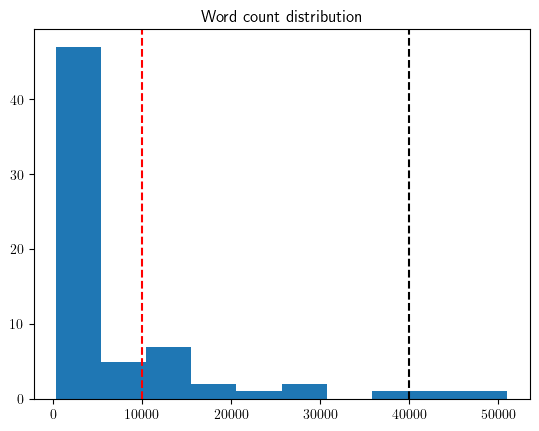

In [9]:
# word count histogram
plt.hist( biblio.df_texts['word_count'])  # creates a histogram of the word counts of the texts
plt.axvline( x = 1e4, color='red', linestyle='--', label='Novella' )
plt.axvline( x = 4e4, color='black', linestyle='--', label='Novel' )
plt.title('Word count distribution')

Text(0.5, 1.0, 'Sentence count distribution')

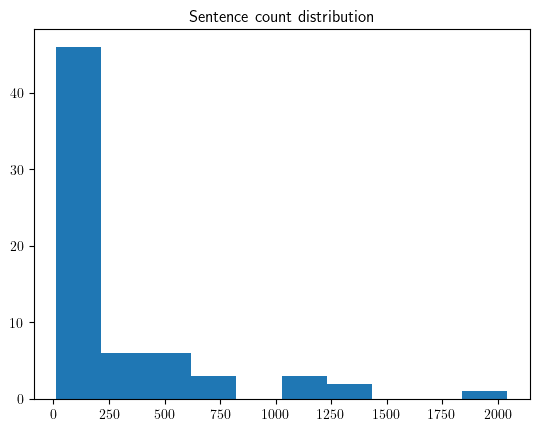

In [10]:
# sentence count histogram
plt.hist( biblio.df_texts['sentence_count'])  # creates a histogram of the sentence counts of the texts
plt.title('Sentence count distribution')

Text(0.5, 1.0, 'Vocabulary size distribution')

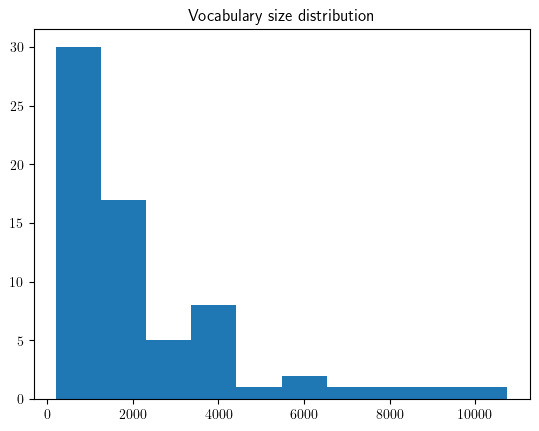

In [11]:
# vocabulary histogram
plt.hist( biblio.df_texts['vocabulary'])  # creates a histogram of the vocabulary sizes of the texts
plt.title('Vocabulary size distribution')

Text(0.5, 1.0, 'Character count distribution')

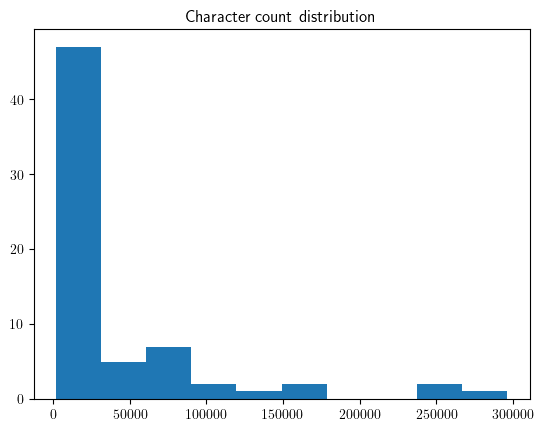

In [12]:
# character count histogram
plt.hist( biblio.df_texts['character_count'])  # creates a histogram of the character counts of the texts
plt.title('Character count distribution')

Text(0.5, 1.0, 'Vocabulary to word count ratio distribution')

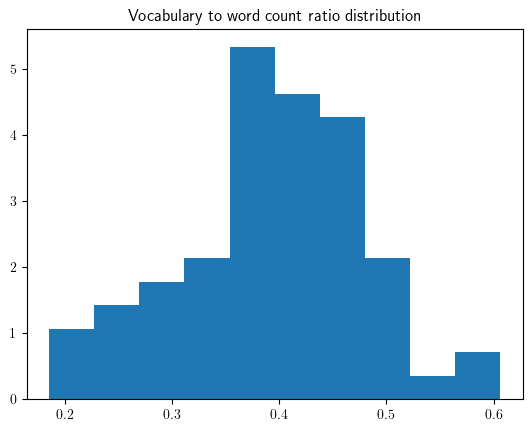

In [13]:
# vocabulary to word count ratio histogram

# vocabulary to word count
vocab_to_word = biblio.df_texts['vocabulary']/biblio.df_texts['word_count']

plt.hist( vocab_to_word, density=True )  # creates a histogram of the vocabulary sizes of the texts
plt.title('Vocabulary to word count ratio distribution')

In [14]:
from scipy import stats

vocab_to_word_mean = np.mean(vocab_to_word)
# calculate mode 
vocab_to_word_std = np.std(vocab_to_word)
vocab_to_word_skew = stats.skew(vocab_to_word)
vocab_to_word_kurt = stats.kurtosis(vocab_to_word)

print(f'Mean of vocabulary to word distribution: {vocab_to_word_mean:.4f}')
print(f'Standard devition of vocabulary to word distribution: {vocab_to_word_std:.4f}')
print(f'Skewness of vocabulary to word distribution: {vocab_to_word_skew:.4f}')
print(f'Kurtosis of vocabulary to word distribution: {vocab_to_word_kurt:.4f}')




Mean of vocabulary to word distribution: 0.3939
Standard devition of vocabulary to word distribution: 0.0852
Skewness of vocabulary to word distribution: -0.1634
Kurtosis of vocabulary to word distribution: 0.1238


### Gamma distribution

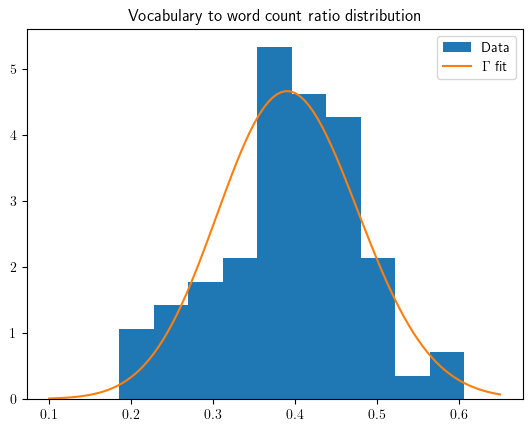

In [15]:

# vocabulary to word count
vocab_to_word = biblio.df_texts['vocabulary']/biblio.df_texts['word_count']

# gamma distribution fit (tried gamma due to assymetry)
from scipy.stats import gamma
params_gamma = gamma.fit(vocab_to_word)  # fits a gamma distribution to the vocabulary

x = np.linspace(0.1, 0.65, 100)
gamma_fit = gamma.pdf(x, *params_gamma)

plt.hist(vocab_to_word, density=True, label='Data')  # creates a histogram of the vocabulary sizes of the texts
plt.plot( x, gamma_fit, label=r'$\Gamma$ fit')  # plots the fitted gamma distribution
plt.title('Vocabulary to word count ratio distribution')
plt.legend()
plt.show()

### Beta distribution

/home/gabriel/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


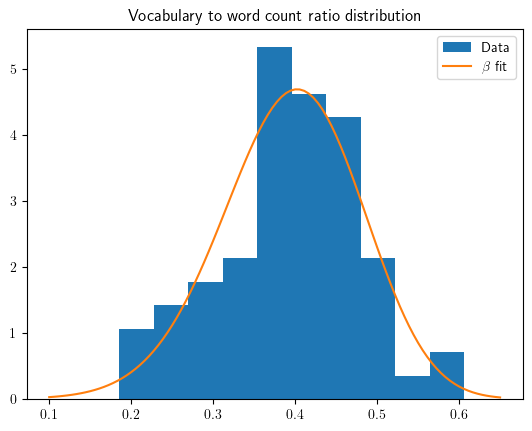

In [16]:
from scipy.stats import beta

params_beta = beta.fit( vocab_to_word )  # fits a beta distribution to the vocabulary

x = np.linspace(0.1, 0.65, 100)
beta_fit = beta.pdf( x, *params_beta)

plt.hist( vocab_to_word, density=True, label='Data' )  # creates a histogram of the vocabulary sizes of the texts
plt.plot( x, beta_fit, label=r'$\beta$ fit')  # plots the fitted beta distribution
plt.title('Vocabulary to word count ratio distribution')
plt.legend()
plt.show()


### Rayleigh distribution

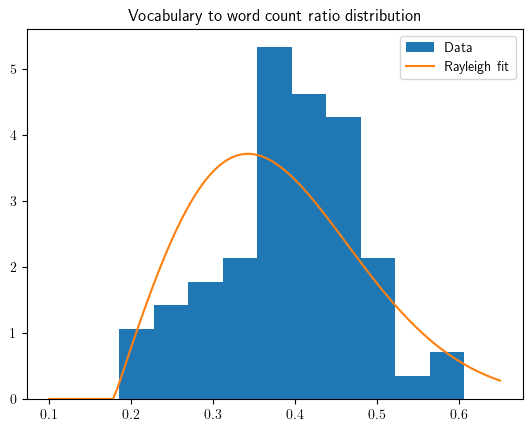

In [17]:
from scipy.stats import rayleigh

params_rayleigh = rayleigh.fit( vocab_to_word )  # fits a beta distribution to the vocabulary

x = np.linspace(0.1, 0.65, 100)
rayleigh_fit = rayleigh.pdf( x, *params_rayleigh)

plt.hist( vocab_to_word, density=True, label='Data' )  # creates a histogram of the vocabulary sizes of the texts
plt.plot( x, rayleigh_fit, label='Rayleigh fit')  # plots the fitted rayleigh distribution
plt.title('Vocabulary to word count ratio distribution')
plt.legend()
plt.show()


### Log-normal distribution

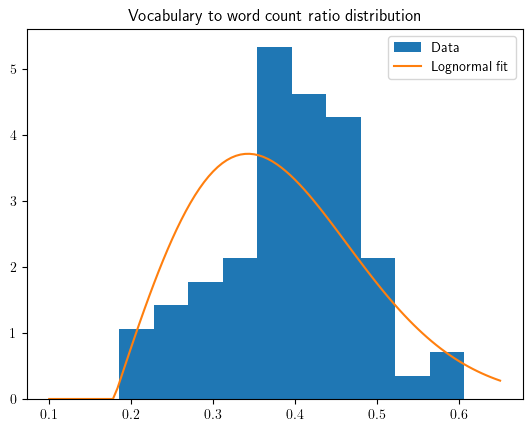

In [18]:
from scipy.stats import lognorm

params_lognorm = rayleigh.fit( vocab_to_word )  # fits a beta distribution to the vocabulary

x = np.linspace(0.1, 0.65, 100)
lognormal_fit = rayleigh.pdf( x, *params_lognorm)

plt.hist( vocab_to_word, density=True, label='Data' )  # creates a histogram of the vocabulary sizes of the texts
plt.plot( x, lognormal_fit, label='Lognormal fit')  # plots the fitted rayleigh distribution
plt.title('Vocabulary to word count ratio distribution')
plt.legend()
plt.show()


### Chi2 Distribution

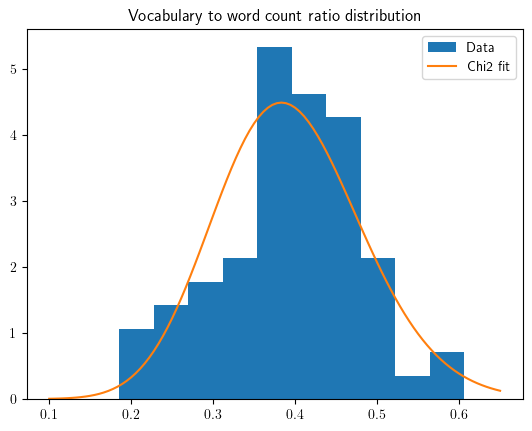

In [19]:
from scipy.stats import chi2

params_chi2 = chi2.fit( vocab_to_word )  # fits a beta distribution to the vocabulary

x = np.linspace(0.1, 0.65, 100)
chi2_fit = chi2.pdf( x, *params_chi2)

plt.hist( vocab_to_word, density=True, label='Data' )  # creates a histogram of the vocabulary sizes of the texts
plt.plot( x, chi2_fit, label='Chi2 fit')  # plots the fitted rayleigh distribution
plt.title('Vocabulary to word count ratio distribution')
plt.legend()
plt.show()


### Statistics of the distributions 

In [20]:
distributions = ['gamma', 'beta', 'rayleigh', 'lognorm', 'chi2']

# Map distribution names to their objects
dist_objects = {
    'gamma': gamma,
    'beta': beta,
    'rayleigh': rayleigh,
    'lognorm': lognorm,
    'chi2': chi2
}

# Map distribution names to their fitted parameters
dist_params = {
    'gamma': params_gamma,
    'beta': params_beta,
    'rayleigh': params_rayleigh,
    'lognorm': params_lognorm,
    'chi2': params_chi2
}

# Build statistics dictionaries
dist_mean = {
    dist_name: round(dist_objects[dist_name].mean(*dist_params[dist_name]),4)
    for dist_name in distributions
}

dist_std = {
    dist_name: round(dist_objects[dist_name].std(*dist_params[dist_name]),4)
    for dist_name in distributions
}

dist_skew = {
    dist_name: round(dist_objects[dist_name].stats(*dist_params[dist_name], moments='s'),4)
    for dist_name in distributions
}

dist_kurt = {
    dist_name: round(dist_objects[dist_name].stats(*dist_params[dist_name], moments='k'),4)
    for dist_name in distributions
}

print("Distribution Statistics:\n")
print(f"Mean: {dist_mean}\n")
print(f"Std Dev: {dist_std}\n")
print(f"Skewness: {dist_skew}\n")
print(f"Kurtosis: {dist_kurt}\n")


Distribution Statistics:

Mean: {'gamma': np.float64(0.394), 'beta': np.float64(0.3939), 'rayleigh': np.float64(0.3838), 'lognorm': np.float64(1.1796), 'chi2': np.float64(0.395)}

Std Dev: {'gamma': np.float64(0.0857), 'beta': np.float64(0.0855), 'rayleigh': np.float64(0.1071), 'lognorm': np.float64(0.1833), 'chi2': np.float64(0.0896)}

Skewness: {'gamma': np.float64(0.0906), 'beta': np.float64(-0.201), 'rayleigh': np.float64(0.6311), 'lognorm': np.float64(0.547), 'chi2': np.float64(0.2625)}

Kurtosis: {'gamma': np.float64(0.0123), 'beta': np.float64(0.0606), 'rayleigh': np.float64(0.2451), 'lognorm': np.float64(0.5367), 'chi2': np.float64(0.1034)}



# 2. Text Statistics

In [21]:
df_works = pd.read_csv('data/bronze/dataframes/lovecraft_works.csv')
df_works

,title,magazine,year_published,collaboration,form
0,the_alchemist,the_united_amateur,1916,NaN,short_story
1,a_reminiscence_of_dr_samuel_johnson,the_united_amateur,1917,NaN,short_story
2,the_beast_in_the_cave,the_vagrant,1918,NaN,short_story
3,beyond_the_wall_of_sleep,pine_cones,1919,NaN,short_story
4,the_white_ship,the_united_amateur,1919,NaN,short_story
...,...,...,...,...,...
94,bothon,amazing_stories,1946,whitehead_henry_s,short_story
95,the_dreamquest_of_unknown_kadath,the_arkham_sampler,1948,NaN,novella
96,sweet_ermengarde_or_the_heart_of_a_country_girl,mirage,1965,NaN,short_story
97,ex_oblivione,magazine_of_horror,1968,NaN,short_story


### Most magazines published


In [22]:
occurrence = df_works['magazine'].value_counts().to_frame()
df_occurrence = occurrence.reset_index()
df_occurrence.columns = ['magazine','count']

In [23]:
df_occurrence['magazine'] = df_occurrence['magazine'].apply(dftools.unnormalize_title)
df_occurrence


,magazine,count
0,Weird Tales,41
1,The United Amateur,6
2,The Vagrant,5
3,The Tryout,4
4,The National Amateur,4
5,Leaves,4
6,The Wolverine,3
7,The Fantasy Fan,3
8,The Californian,3
9,Astounding Stories,2


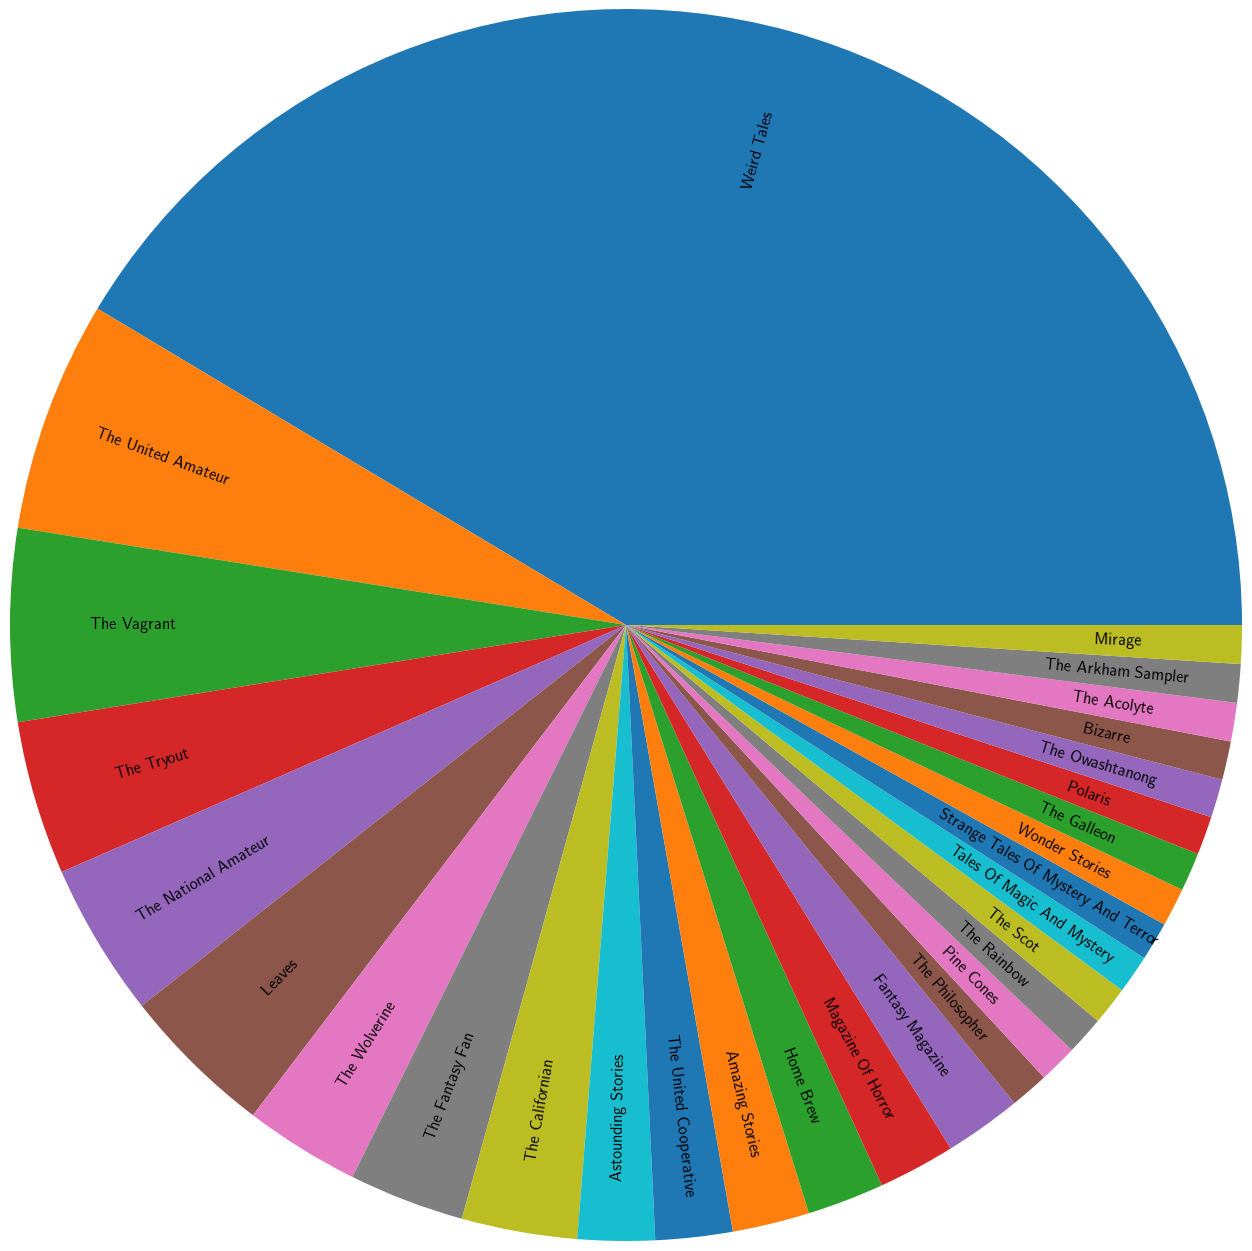

In [24]:
fig, ax = plt.subplots(figsize = (10,10))

wedges, texts = ax.pie(
    df_occurrence['count'],
    labels=df_occurrence['magazine'],
    radius=2,
    textprops={'fontsize': 12},
    labeldistance=0.8,
)

# Rotate each label
for wedge, text in zip(wedges, texts):
    angle = (wedge.theta1 + wedge.theta2) / 2

    if angle > 90 and angle < 270:
        angle += 180  # flip text

    text.set_rotation(angle)
    text.set_horizontalalignment('center')

plt.show()

<BarContainer object of 29 artists>

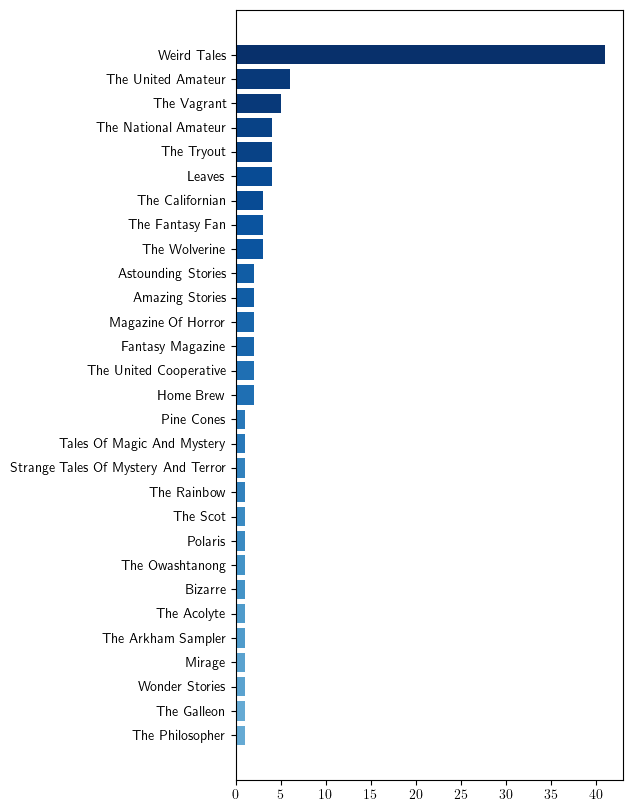

In [25]:
# bar plot 
df_occurrence = df_occurrence.sort_values('count')
fig, ax = plt.subplots(figsize = (5,10))

cmap = plt.cm.Blues.resampled(2*len('number_of_texts'))

ax.barh(df_occurrence['magazine'],
       df_occurrence['count'],
       #color = plt.cm.Blues(np.linspace(0.1, 1, len('number_of_texts'))),
       color = cmap(np.linspace(0.5,1,2*len('number_of_texts')))
       )

## Year with most publications 


In [26]:
df_years = df_works['year_published'].value_counts().to_frame()
df_years = df_years.reset_index()
df_years.columns = ['year_published','count']

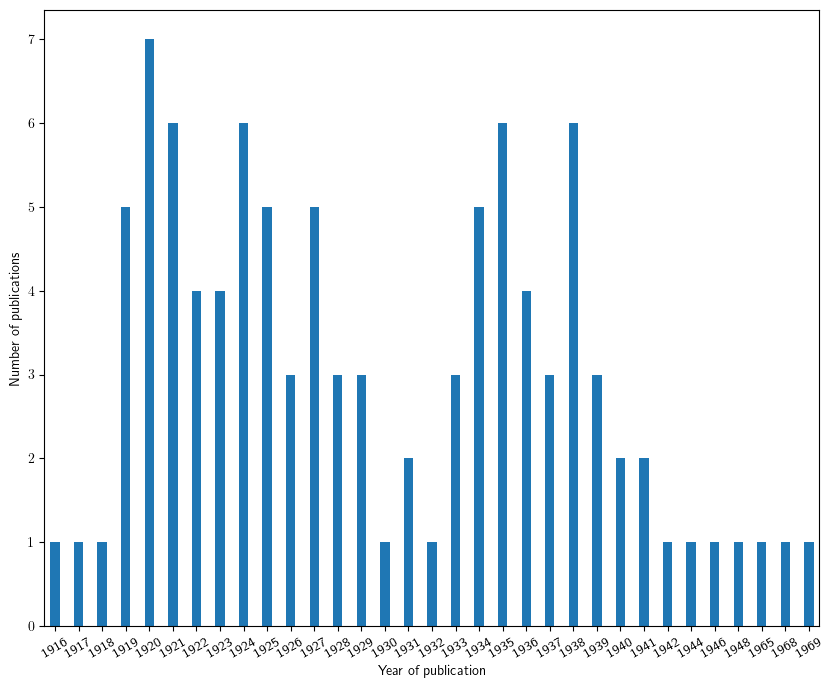

In [27]:
df_years = df_years.sort_values('year_published')


df_years.plot(kind="bar", 
              x="year_published", 
              y="count", 
              legend=False, 
              figsize=(10,8),
              width=0.4
              )
plt.xticks(rotation=30)
plt.ylabel('Number of publications')
plt.xlabel('Year of publication')

plt.show()

# mudar forma da série temporal e colocar ano dos eventos

## Most proeminent form of story


In [28]:
df_form = df_works['form'].value_counts().to_frame()
df_form = df_form.reset_index()
df_form.columns = ['form','count']

df_form['form'] = df_form['form'].apply(dftools.unnormalize_title)

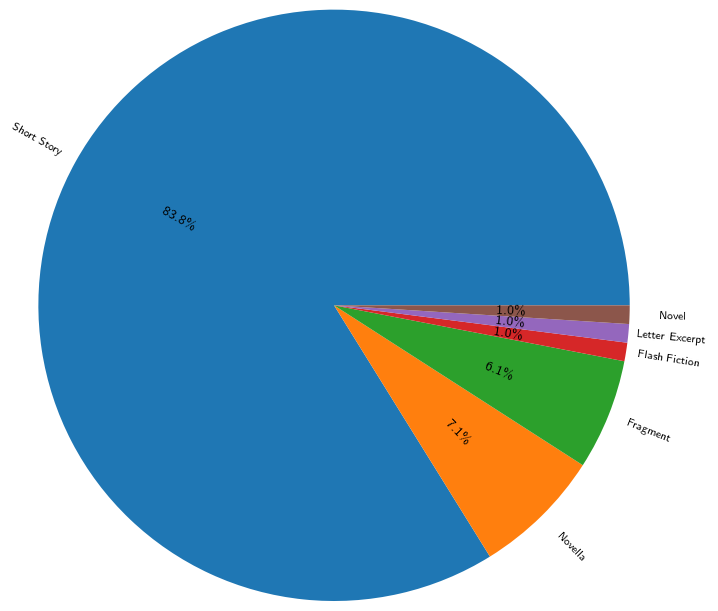

In [29]:
fig, ax = plt.subplots()

wedges, texts, autotexts = ax.pie(
    df_form['count'],
    labels=df_form['form'],
    radius=2,
    autopct="%1.1f%%",  #  add this
    textprops={'fontsize': 8},
    labeldistance=1.15,
    pctdistance=0.6     #  controls position of percentages
)

# Rotate labels
for wedge, text in zip(wedges, texts):
    angle = (wedge.theta1 + wedge.theta2) / 2

    if 90 < angle < 270:
        angle += 180

    text.set_rotation(angle)
    text.set_horizontalalignment('center')

# Rotate percentages too (optional but nicer)
for wedge, autotext in zip(wedges, autotexts):
    angle = (wedge.theta1 + wedge.theta2) / 2

    if 90 < angle < 270:
        angle += 180

    autotext.set_rotation(angle)
    autotext.set_fontsize(10)

plt.show()

## Most common collaborator


In [30]:
df_collab = df_works['collaboration'].value_counts().to_frame()
df_collab = df_collab.reset_index()
df_collab.columns = ['collaborator', 'count']
df_collab

,collaborator,count
0,heald_hazel,5
1,eddy_c_m_jr,4
2,bishop_zealia_brown_reed,3
3,barlow_r_h,3
4,whitehead_henry_s,2
5,with_jackson_winifred_v,2
6,with_barlow_r_h,2
7,rimel_duane_w,2
8,de_castro_adolphe,2
9,davis_sonia_h,1


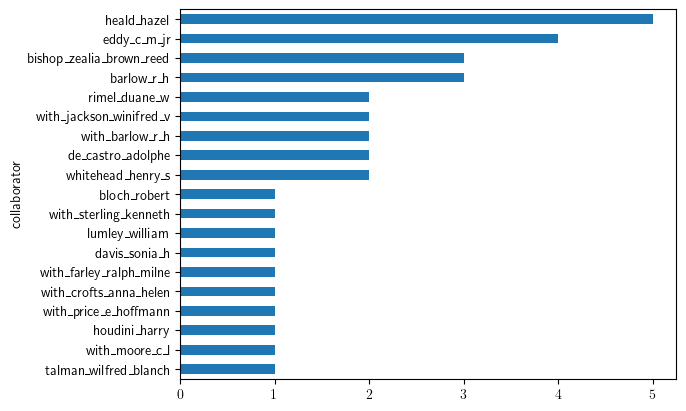

In [31]:
df_collab = df_collab.sort_values('count')
df_collab.plot(kind='barh',x='collaborator', y='count', legend = False)
plt.show()